In [7]:
import numpy as np
import seaborn as sns
import pandas as pd

In [ ]:
# Crating a DataSet with help of numpy 
np.random.seed(42)
dates = pd.date_range(start="2026-01-01", periods=100, freq="D")
categories = ["Electronics", "Clothing", "Home & Kitchen", "Books"]
sex= ["Male", "Female"]

data = {
    "Date": np.random.choice(dates, size = 500),
    "CustomerID": range(1001, 1001 + 500),
    "Sex" : np.random.choice(sex, size = 500, p = [0.45, 0.55]),
    "Category": np.random.choice(categories, size=500, p=[0.4, 0.3, 0.2, 0.1]),
    "Transaction_Amount": np.random.normal(loc=800, scale=300, size=500)
}

df = pd.DataFrame(data)

In [21]:
# Dropping Duplicate values
df.drop_duplicates(inplace=True)

# handle missing value (null/NaN)
df.dropna(subset=["CustomerID"])

df["Transaction_Amount"] = df["Transaction_Amount"].fillna(0)

print(df.info())
print(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                500 non-null    datetime64[us]
 1   CustomerID          500 non-null    int64         
 2   Sex                 500 non-null    str           
 3   Category            500 non-null    str           
 4   Transaction_Amount  500 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(2)
memory usage: 19.7 KB
None
Date                  0
CustomerID            0
Sex                   0
Category              0
Transaction_Amount    0
dtype: int64


In [26]:
# calculate total sales and average revenue

t_sales = df["Transaction_Amount"].sum()

# average revenue per customer (ARPU) 
ARPU = t_sales/500

print(f"Total Sales : Rs{t_sales:,.2f}")
print(f"Avg Revenue per customer : Rs{ARPU:,.2f}")

Total Sales : Rs399,673.15
Avg Revenue per customer : Rs799.35


In [34]:
top_5 = (df.groupby("CustomerID")["Transaction_Amount"]
         .sum()
         .nlargest(5)
    )
print(top_5)
df

CustomerID
1001    1689.503106
1078    1681.325854
1287    1539.463291
1141    1498.585703
1435    1490.123026
Name: Transaction_Amount, dtype: float64


,Date,CustomerID,Sex,Category,Transaction_Amount
0,2026-02-21,1001,Male,Clothing,1689.503106
1,2026-04-03,1002,Male,Electronics,771.011328
2,2026-01-15,1003,Female,Clothing,520.035978
3,2026-03-13,1004,Male,Electronics,1025.997728
4,2026-03-02,1005,Male,Electronics,461.651834
...,...,...,...,...,...
495,2026-03-04,1496,Female,Books,759.427131
496,2026-03-10,1497,Female,Electronics,944.017874
497,2026-01-22,1498,Male,Electronics,390.361393
498,2026-04-03,1499,Male,Home & Kitchen,856.954351


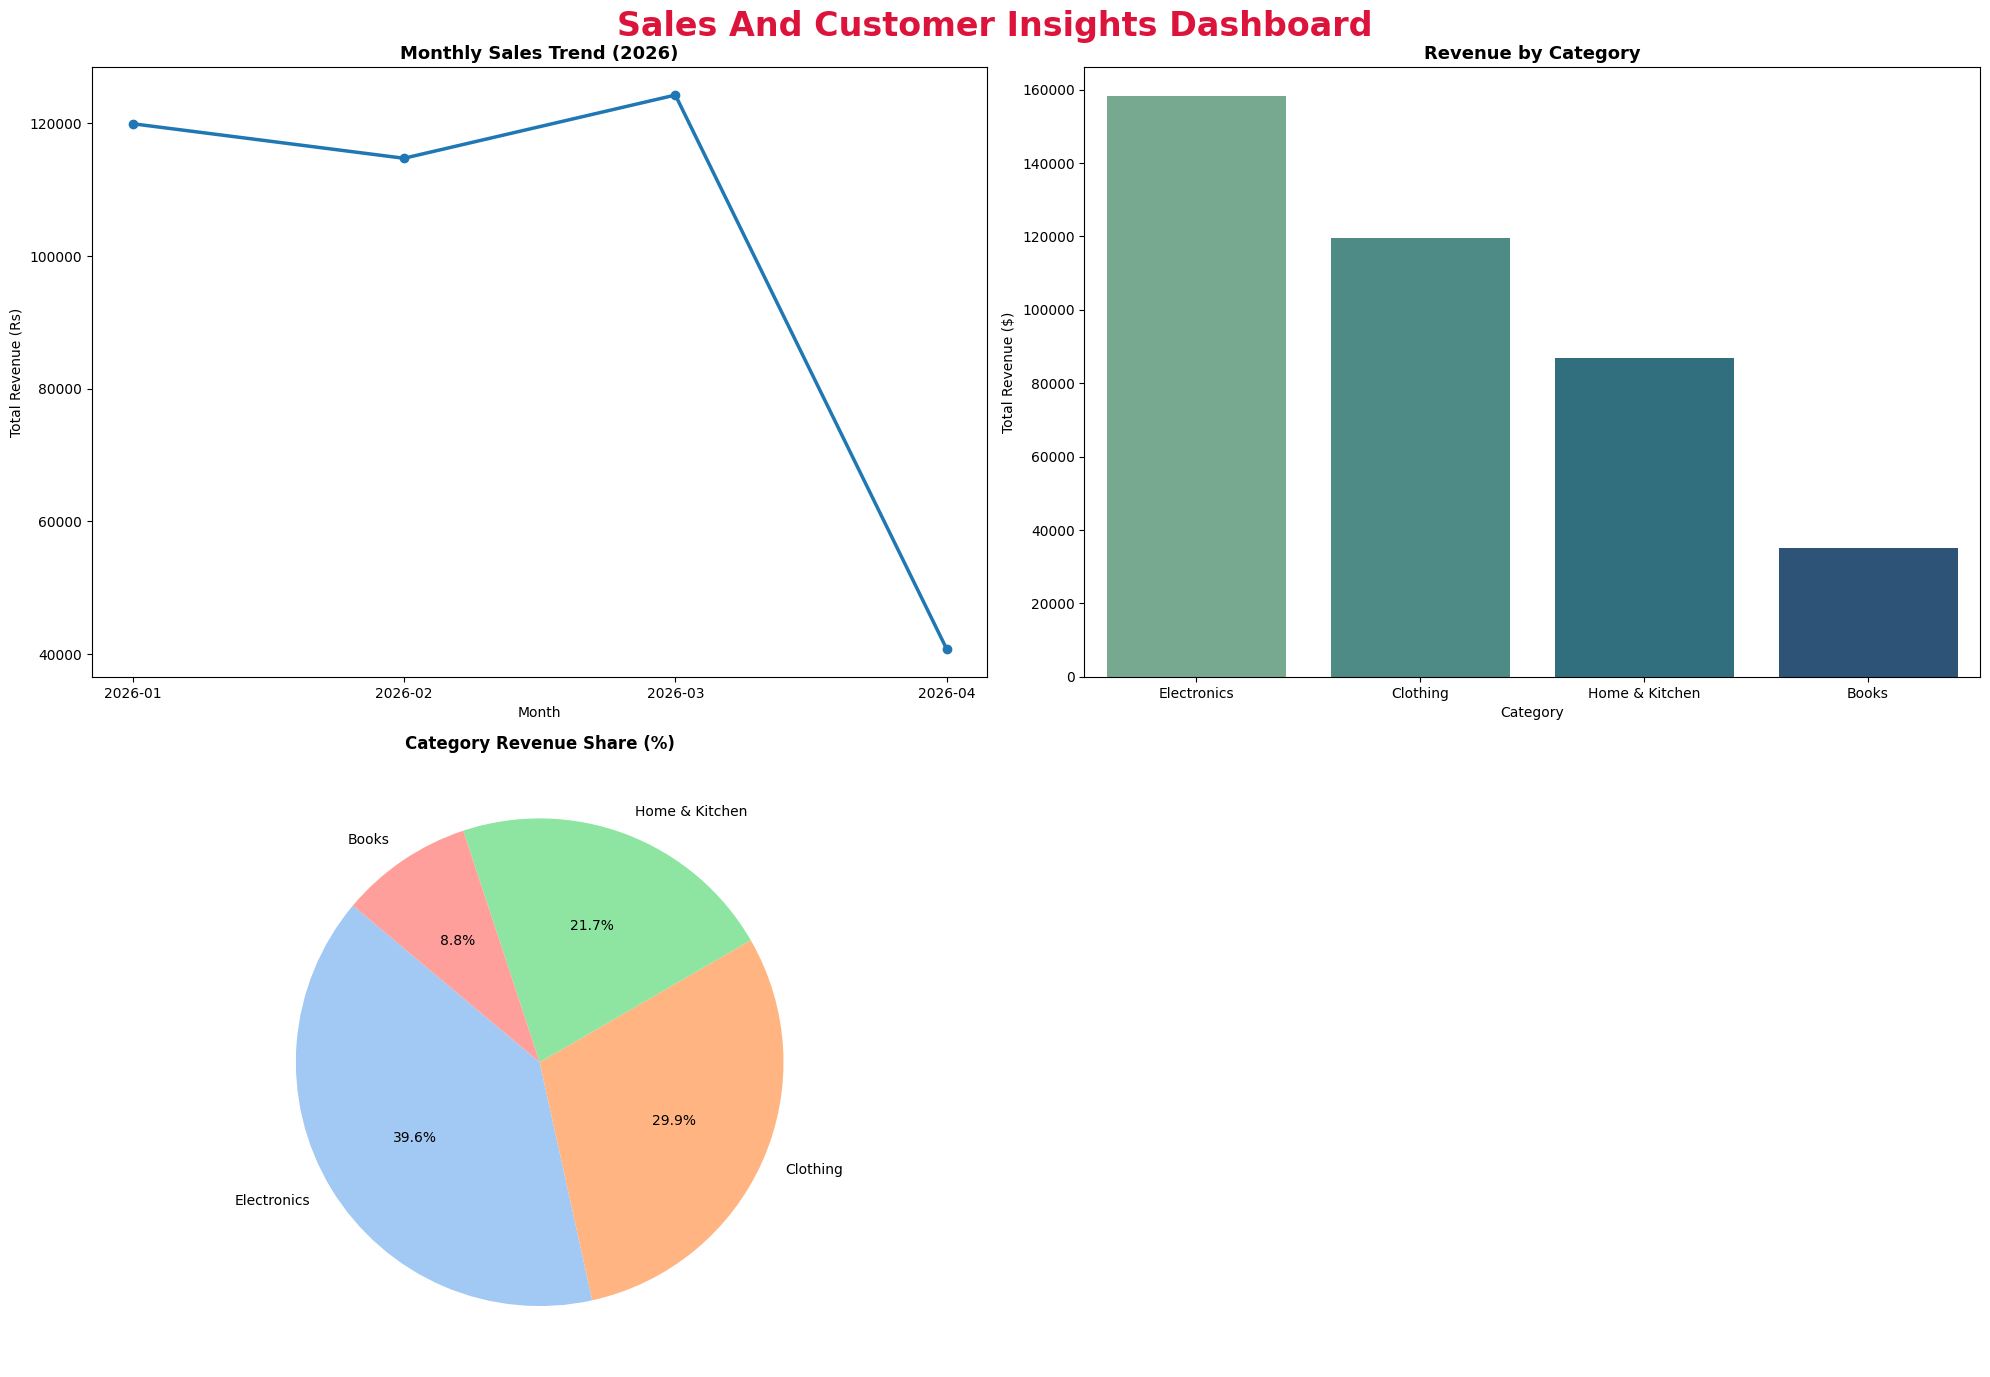

In [67]:
#visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle("Sales And Customer Insights Dashboard", fontweight='bold', fontsize = 24, color = "crimson")

#Line Chart(Sales Trend)
# 1. Line Chart: Sales Trend (Monthly)
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Transaction_Amount'].sum()
monthly_sales.index = monthly_sales.index.astype(str)
axes[0,0].plot(monthly_sales.index, monthly_sales.values, marker='o', color='#1f77b4', linewidth=2.5)
axes[0,0].set_title('Monthly Sales Trend (2026)', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Total Revenue (Rs)')

#Bar Chart : top products
# 1. Reset index so 'Category' and 'Transaction_Amount' are column names
category_sales = (
    df.groupby('Category')['Transaction_Amount'].sum().sort_values(ascending=False).reset_index()
)

# 2. Use sns.barplot and pass the axis to the `ax` parameter
# (Use axes[1] if 1D array from plt.subplots(1, 3), or axes[0, 1] if 2D grid)
sns.barplot(data=category_sales, x='Category', y='Transaction_Amount', palette='crest', ax=axes[0, 1] , hue = 'Category'
)

axes[0, 1].set_title('Revenue by Category', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Category')
axes[0, 1].set_ylabel('Total Revenue ($)')

# Pie Chart (Category Distribution Share)
axes[1,0].pie(
    category_sales['Transaction_Amount'],
    labels=category_sales['Category'],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel')
)
axes[1,0].set_title('Category Revenue Share (%)', fontsize=12, fontweight='bold')



#removing the last subplot (bottom right) for a cleaner look
fig.delaxes(axes[1, 1])

plt.tight_layout()
plt.show()